# Expected Credit Loss

La pérdida esperada de un préstamo se descompone en tres piezas:

- PD (Probability of Default): probabilidad de que ese préstamo impague.

- LGD (Loss Given Default): qué % de lo que debe se pierde realmente si impaga (1 – tasa de recuperación).

- EAD (Exposure at Default): cuánto queda pendiente en el momento del impago.

La pérdida esperada de cada préstamo es ECL_i = PD_i × LGD_i × EAD_i, y la pérdida esperada de la cartera es la suma de todos los ECL_i. 
### Importante!
Variables de originación (disponibles en el momento de conceder el préstamo ~37 en total): importe financiado, plazo, tipo de interés, grade, ingresos anuales, situación de vivienda, antigüedad laboral, finalidad del préstamo, estado/región, ratio cuota-ingresos, líneas de crédito abiertas, morosidad previa, consultas de crédito recientes, saldo y uso del revolving, antigüedad de la primera línea de crédito, fecha de emisión, método de desembolso, entre otras.

Variables de desempeño (posteriores a la concesión, construidas a partir del histórico de pagos): principal recibido, intereses recibidos, comisiones por mora recibidas, y principal pendiente.

### Librerias 

In [1]:
import pandas as pd 
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pl.Config.set_tbl_rows(50)
pl.Config.set_fmt_str_lengths(60)

# Tema visual
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize': (5, 4),

    'axes.facecolor': '#FFFFFF',
    'figure.facecolor': '#FFFFFF',

    'axes.edgecolor': '#D0D7DE',

    'grid.color': '#E5E7EB',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,

    'font.size': 10,
})

RANDOM_STATE = 42

## Carga de datos

Convertimos el CSV a parquet para mayor eficiencia de lectura.

In [2]:
# features = pl.read_csv("../data/raw/X.csv")
# features.write_parquet("../data/raw/X.parquet")

# target = pl.read_csv("../data/raw/target.csv")
# target.write_parquet("../data/raw/target.parquet")

In [3]:
features = pl.read_parquet("../data/raw/X.parquet")
target = pl.read_parquet("../data/raw/target.parquet")

# Unimos los features con el target
df = features.with_columns(
    target["y"]
)
print(f"Filas: {df.height:,}  |  Columnas: {df.width}")

print(features.shape)
print(target.shape)

Filas: 2,139,643  |  Columnas: 46
(2139643, 45)
(2139643, 1)


Taxonomia de variables

In [4]:
TARGET = "y"

LEAKAGE_VARS = ['grade']

PERFORMANCE_VARS = [
    'remaining_princ_for_tot_amnt_fund',
    'paym_rec_for_tot_amnt_fund',
    'princ_rec',
    'interest_rec',
    'late_fees_rec'
]

NUM = [col for col, dtype in df.schema.items() if dtype.is_numeric() and col != 'y']

NUM_ORIG = [col for col in NUM if col not in PERFORMANCE_VARS]

CAT_ORIG = [col for col, dtype in df.schema.items() if dtype == pl.String and col != 'grade']

ORIG_VARS = NUM_ORIG + CAT_ORIG


print(f"Variables de originación: {len(ORIG_VARS)}  (numéricas: {len(NUM_ORIG)}, categóricas: {len(CAT_ORIG)})")
print(f"Variables de desempeño (LGD/EAD): {len(PERFORMANCE_VARS)}")
print(f"Variables de leakage excluidas de PD: {LEAKAGE_VARS}")

Variables de originación: 39  (numéricas: 29, categóricas: 10)
Variables de desempeño (LGD/EAD): 5
Variables de leakage excluidas de PD: ['grade']


Verificamos si existen duplicados

In [5]:
n_dup_rows = df.is_duplicated().sum()

print(f'Filas duplicadas de orginacion: {n_dup_rows}')

Filas duplicadas de orginacion: 0


Continuamos con el análisis de la variable objetivo `y`. 

In [6]:
target['y'].value_counts(normalize=True)

y,proportion
i64,f64
1,0.13073
0,0.86927


Vemos que cerca del 87% los prestamos no han caido en default, y el 13% si cayeron en default. Adicionalmente, vemos que el target esta desbalanceado. 

## Valores faltantes.

### Grupo 1. 

Este tipo de variables responde: ¿Cuántos meses han pasado desde X?" - Si nunca ocurrió X, es perfectamente posible que no exista un número de meses. 

1 Cliente A → tuvo morosidad hace 8 meses → 8

2 Cliente B → nunca tuvo morosidad → NULL



- mths_since_recent_bankcard_delinq
- mths_since_recent_revol_delinq
- mths_since_last_delinq
- mths_since_last_installment_acc_op

### Grupo 2. 

Variables ~40% null, buscar patrones y comportamientos de default

- bal_to_cred_lim
- num_open_trades_in_6mths
- num_installment_acc_op_in_12mths
- num_installment_acc_op_in_24mths
- num_rev_trades_op_in_12mths
- num_rev_trades_op_in_24mths
- max_bal_owed
- num_inq

## Grupo 3. 

Se podria considerar Unknown

- emp_title

Mecanismo para el tratamiento de valores faltantes. 

- **MCAR** (*Missing Completely At Random*): falta al azar, sin relación con ningún otro dato. Poco común en datos reales de negocio.
- **MAR** (*Missing At Random*): la probabilidad de que falte depende de **otras variables observadas** (p. ej. falta más en años antiguos porque ese campo no se recogía entonces). Podemos explicarlo y tratarlo con esa información.
- **MNAR** (*Missing Not At Random*): la probabilidad de que falte depende del **propio valor** que falta (p. ej. si "meses desde la última morosidad" falta porque el cliente **nunca** tuvo morosidad, el hecho de faltar ya es información: "sin incidencias").


In [7]:
n_filas = df.height

resumen_filas = []

df[ORIG_VARS].columns

for c in df[ORIG_VARS].columns:
    n_missing = df[c].null_count()
    resumen_filas.append({
        'columna' : c,
        'dtype' : str(df.schema[c]),
        'n_unicos': df[c].n_unique(),
        'n_missing': n_missing,
        'pct_missing':round(n_missing/n_filas * 100, 2)
    })

resumen = pl.DataFrame(resumen_filas).sort('pct_missing', descending = True)

with pl.Config(tbl_rows = -1):
    print(resumen.filter(pl.col('n_missing') > 0))

shape: (13, 5)
┌────────────────────────────────────┬────────┬──────────┬───────────┬─────────────┐
│ columna                            ┆ dtype  ┆ n_unicos ┆ n_missing ┆ pct_missing │
│ ---                                ┆ ---    ┆ ---      ┆ ---       ┆ ---         │
│ str                                ┆ str    ┆ i64      ┆ i64       ┆ f64         │
╞════════════════════════════════════╪════════╪══════════╪═══════════╪═════════════╡
│ mths_since_recent_bankcard_delinq  ┆ Int64  ┆ 177      ┆ 1643502   ┆ 76.81       │
│ mths_since_recent_revol_delinq     ┆ Int64  ┆ 178      ┆ 1433891   ┆ 67.02       │
│ mths_since_last_delinq             ┆ Int64  ┆ 173      ┆ 1090997   ┆ 50.99       │
│ mths_since_last_installment_acc_op ┆ Int64  ┆ 404      ┆ 905256    ┆ 42.31       │
│ num_open_trades_in_6mths           ┆ Int64  ┆ 20       ┆ 865656    ┆ 40.46       │
│ num_installment_acc_op_in_12mths   ┆ Int64  ┆ 20       ┆ 865656    ┆ 40.46       │
│ num_installment_acc_op_in_24mths   ┆ Int64  ┆ 32

### Análisis exploratorio (EDA)

Empezamos el análisis con las variables numéricas. Empezando por analisis descriptivo. 

In [8]:
resumen_describe = df[NUM_ORIG].describe().transpose(
    include_header = True,
    header_name = 'variable'
)

with pl.Config(tbl_rows = -1, tbl_cols = -1):
    print(resumen_describe)

shape: (30, 10)
┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ variabl ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column │
│ e       ┆ 0       ┆ 1       ┆ 2       ┆ 3       ┆ 4       ┆ 5       ┆ 6       ┆ 7       ┆ _8     │
│ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---    │
│ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str    │
╞═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│ statist ┆ count   ┆ null_co ┆ mean    ┆ std     ┆ min     ┆ 25%     ┆ 50%     ┆ 75%     ┆ max    │
│ ic      ┆         ┆ unt     ┆         ┆         ┆         ┆         ┆         ┆         ┆        │
│ funded_ ┆ 2139643 ┆ 0.0     ┆ 14782.2 ┆ 9033.08 ┆ 500.0   ┆ 8000.0  ┆ 12250.0 ┆ 20000.0 ┆ 40000. │
│ amnt    ┆ .0      ┆         ┆ 9610033 ┆ 5915039 ┆         ┆         ┆    

- El describe nos anticipa que existe 3 variables valores muy altos como:  `annual_income`, `funded_amnt` o `total_credit_revolving_bal`, posbiles outliers, muy común en variables monetarias. 

- `dept_paym_income_ratio` (DTI): mínimo de **-1**, un ratio negativo no tiene sentido económico — apunta a un código de "missing"/error codificado como -1 más que a un valor real.


A continuación, escogeremos algunas variables claves numericas y graficaremos para observar su comportamiento. 

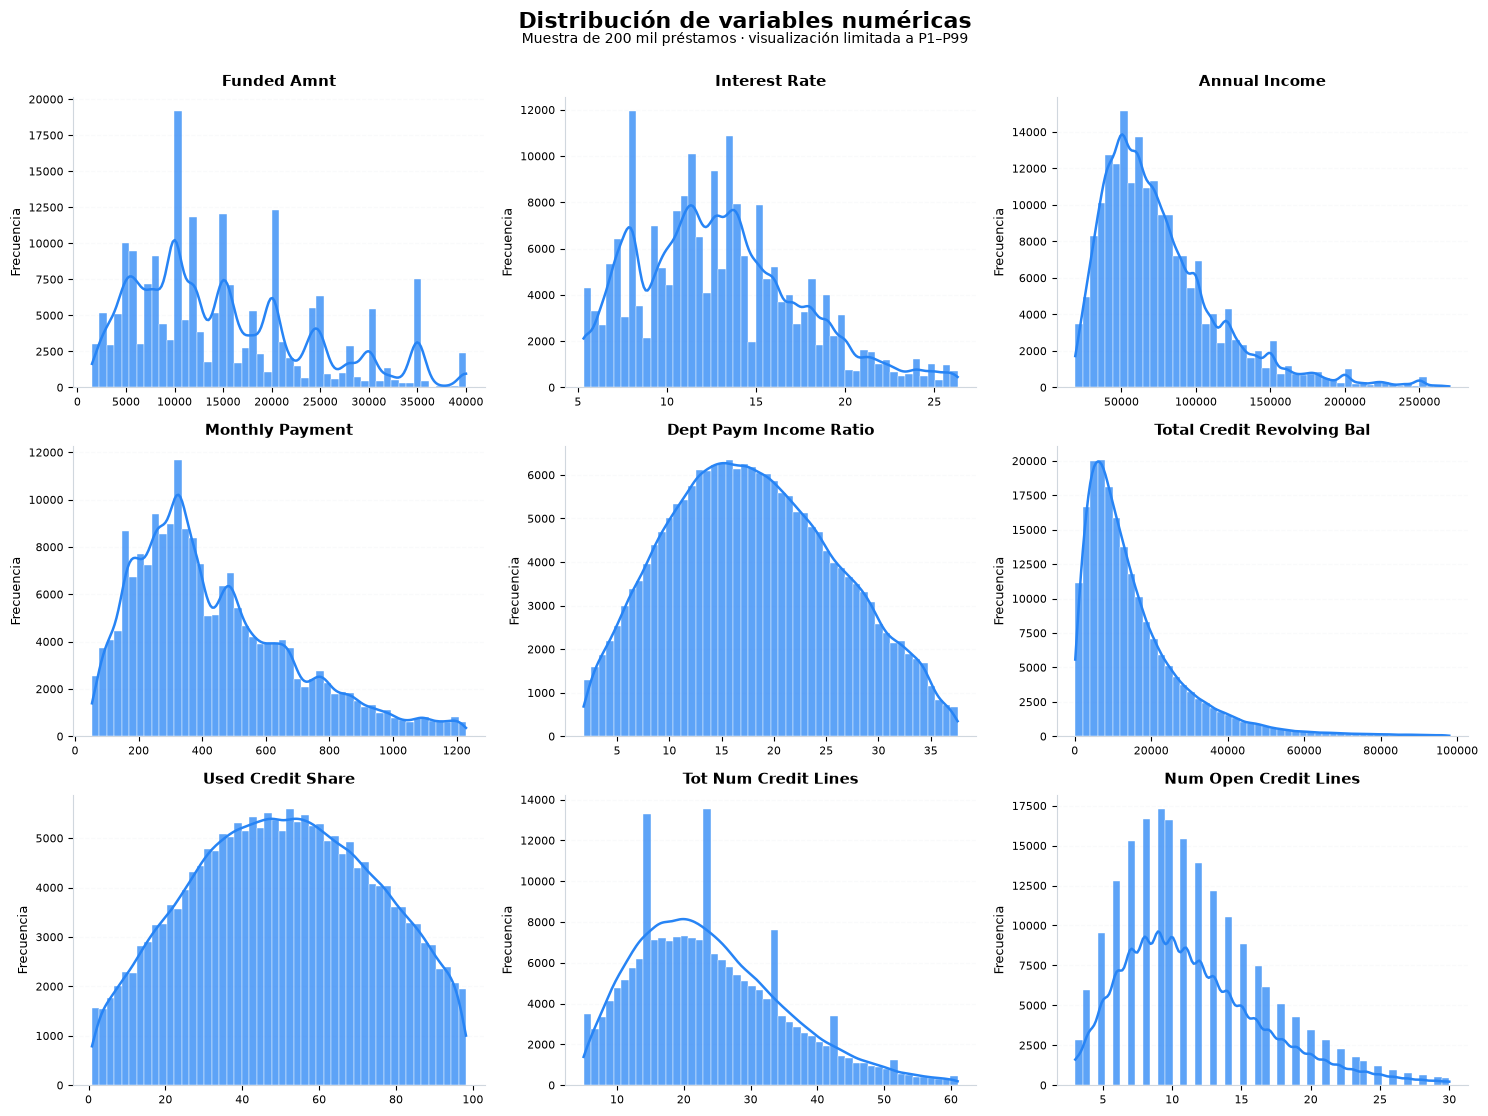

In [9]:
cols_clave = [
    'funded_amnt',
    'interest_rate',
    'annual_income',
    'monthly_payment',
    'dept_paym_income_ratio',
    'total_credit_revolving_bal',
    'used_credit_share',
    'tot_num_credit_lines',
    'num_open_credit_lines'
]

# Muestra para visualización
sample_pd = (
    df.select(cols_clave)
    .sample(n=200_000, seed=RANDOM_STATE)
    .to_pandas()
)

fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 11)
)

for ax, col in zip(axes.flat, cols_clave):

    # Eliminar nulos
    data = sample_pd[col].dropna()

    # Recorte únicamente para visualizar la forma
    lo = data.quantile(0.01)
    hi = data.quantile(0.99)

    data_plot = data[(data >= lo) & (data <= hi)]

    sns.histplot(
        data=data_plot,
        bins=50,
        kde=True,
        ax=ax,
        color="#2784F5",
        alpha=0.75,
        edgecolor="white",
        linewidth=0.3,
        line_kws={
            "linewidth": 1.8
        }
    )

    # Título
    ax.set_title(
        col.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold",
        pad=8
    )

    # Ejes
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia", fontsize=9)

    # Grid
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.20
    )
    ax.set_axisbelow(True)

    # Limpiar bordes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Tamaño de ticks
    ax.tick_params(
        axis="both",
        labelsize=8
    )

plt.suptitle(
    "Distribución de variables numéricas",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

fig.text(
    0.5,
    0.98,
    "Muestra de 200 mil préstamos · visualización limitada a P1–P99",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

Observamos que algunas variables como `annual_income`, `total_credit_revolving_bal` entre otras tienen asimetria positiva marcada (sesgo hacia la derecha), candidatos a una transformación logarítmica para modelos como LR.

Continuamos con analisis de variables categóricas de originación

In [10]:
cat_card = pl.DataFrame({
    "variable"  :   CAT_ORIG,
    "n_unique"  :   [df[col].n_unique() for col in CAT_ORIG],
    "nulls"     :   [df[col].null_count() for col in CAT_ORIG],
    "mode"      :   [df[col].drop_nulls().mode()[0] for col in CAT_ORIG]
})

print(cat_card.sort("n_unique", descending=True))

shape: (10, 4)
┌────────────────────────┬──────────┬────────┬────────────────────┐
│ variable               ┆ n_unique ┆ nulls  ┆ mode               │
│ ---                    ┆ ---      ┆ ---    ┆ ---                │
│ str                    ┆ i64      ┆ i64    ┆ str                │
╞════════════════════════╪══════════╪════════╪════════════════════╡
│ emp_title              ┆ 496835   ┆ 148490 ┆ Teacher            │
│ addr_state             ┆ 51       ┆ 0      ┆ CA                 │
│ loan_purpose           ┆ 14       ┆ 0      ┆ debt_consolidation │
│ emp_length             ┆ 12       ┆ 0      ┆ 10+ years          │
│ issue_date_month       ┆ 12       ┆ 0      ┆ Oct                │
│ earliest_cr_line_month ┆ 12       ┆ 0      ┆ Aug                │
│ home_ownership_status  ┆ 4        ┆ 0      ┆ MORTGAGE           │
│ verification_status    ┆ 3        ┆ 0      ┆ Source Verified    │
│ initial_list_status    ┆ 2        ┆ 0      ┆ w                  │
│ disbursement_method    ┆ 2     

- `emp_title` tiene ~ 496k valores únicos. Se podria normalizar el texto, agrupar por sector, etc. Y los valores faltantes se podría tratar con 'unknow'. 
- El resto de variables > 12 se podría tratar con un onehot para la modelización.

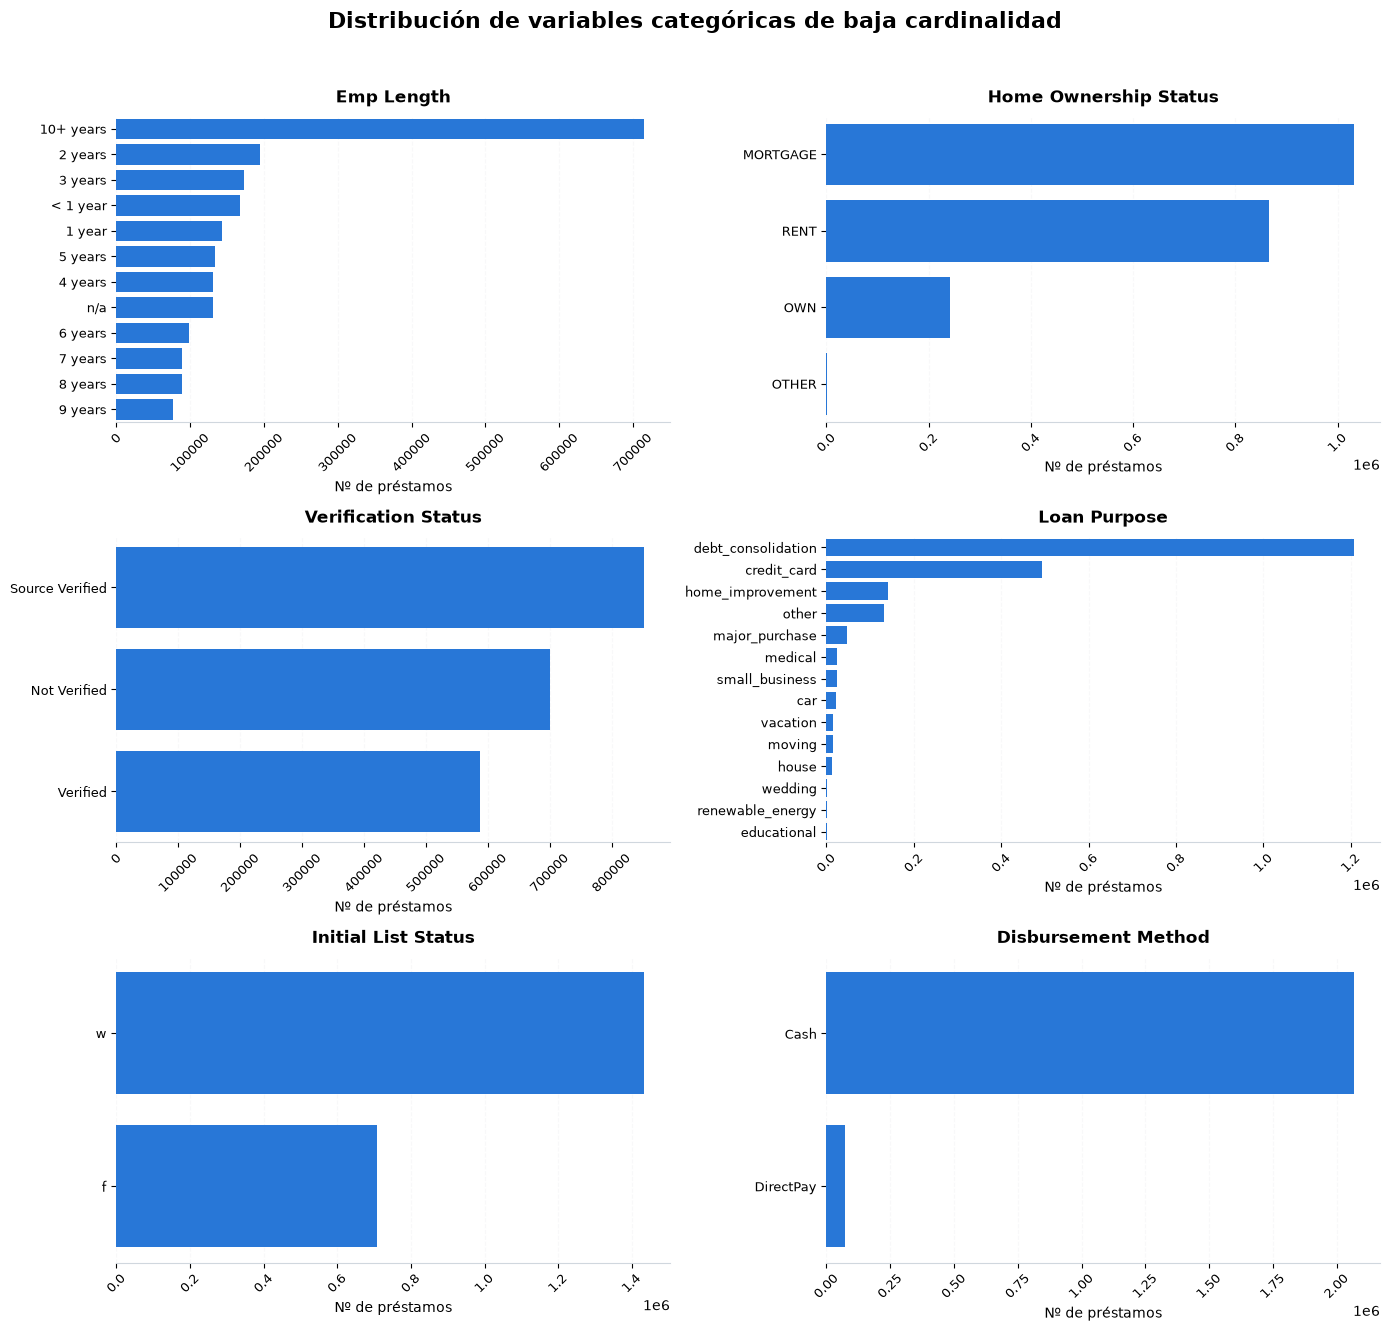

In [11]:
low_card = [
    "emp_length",
    "home_ownership_status",
    "verification_status",
    "loan_purpose",
    "initial_list_status",
    "disbursement_method"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 13))

for ax, col in zip(axes.flat, low_card):

    vc = (
        df.group_by(col)
        .len()
        .sort("len", descending=True)
        .to_pandas()
    )

    sns.barplot(
        data=vc,
        y=col,
        x="len",
        ax=ax,
        color="#0B74F4"   # azul suave/moderno
    )

    # Título
    ax.set_title(
        col.replace("_", " ").title(),
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    # Ejes
    ax.set_xlabel("Nº de préstamos", fontsize=10)
    ax.set_ylabel("")

    # Grid horizontal suave
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )
    ax.set_axisbelow(True)

    # Limpiar bordes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Etiquetas de categorías
    ax.tick_params(axis="y", labelsize=9)

    # Si quieres las etiquetas numéricas del eje X inclinadas
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)

plt.suptitle(
    "Distribución de variables categóricas de baja cardinalidad",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

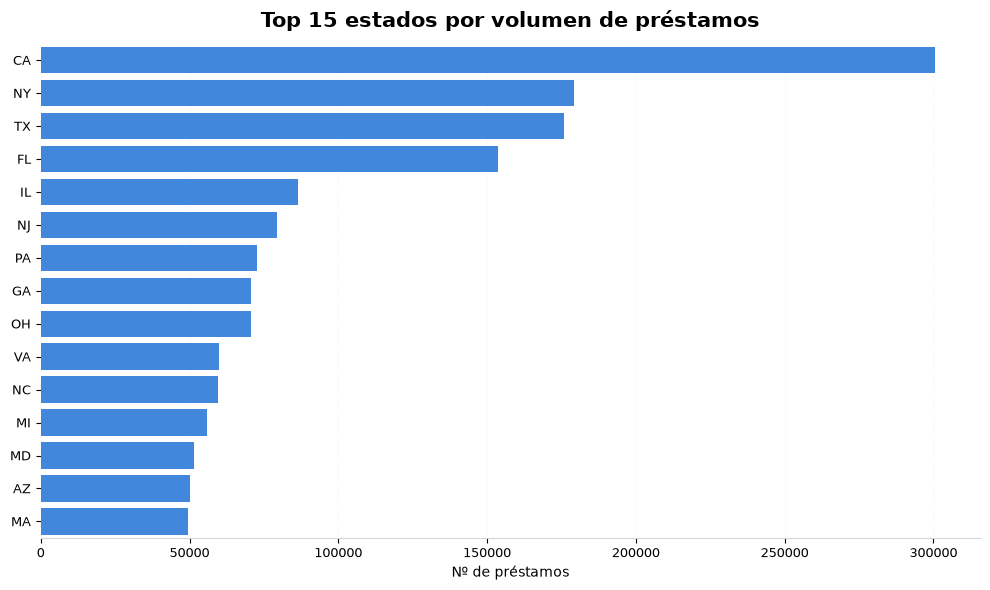

In [12]:
top_states = (
    df.group_by("addr_state")
      .len()
      .sort("len", descending=True)
      .head(15)
      .to_pandas()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_states,
    x="len",
    y="addr_state",
    color="#2784F5",
    ax=ax
)

# Título
ax.set_title(
    "Top 15 estados por volumen de préstamos",
    fontsize=15,
    fontweight="bold",
    pad=12
)

# Ejes
ax.set_xlabel("Nº de préstamos", fontsize=10)
ax.set_ylabel("")

# Grid horizontal
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.20
)

ax.set_axisbelow(True)

# Limpiar bordes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Tamaño de etiquetas
ax.tick_params(
    axis="both",
    labelsize=9
)

plt.tight_layout()
plt.show()

## Análisis de valores faltantes. 

### ~ 40% de valores faltantes.

Todas estas variables tienen ~ 40% de valores faltantes. (`num_open_trades_in_6mths`, `num_installment_acc_op_in_12mths`, `num_installment_acc_op_in_24mths`, `num_rev_trades_op_in_12mths`, `num_rev_trades_op_in_24mths`, `max_bal_owed`, `bal_to_cred_lim`, `num_inq`, `mths_since_last_installment_acc_op`). Se sospecha que podrían tener un patron similar o que podría estar relacionado con la estructura de base de datos.

Empezaremos con una variable de muestra `issue_date_year` y veremos la relación con el tiempo `issue_date_year`

In [13]:
missing_var = [
    "num_inq", 
    "mths_since_recent_bankcard_delinq",
    "bal_to_cred_lim", 
    "mths_since_last_delinq"
]

years_nulls = (
    df.group_by('issue_date_year')
    .agg([pl.len().alias('n_prestamos')] + 
        [(pl.col(col).null_count() / pl.len() * 100).round(1).alias(f'%null_{col}')
         for col in missing_var])
    .sort('issue_date_year')
)

# with pl.Config(tbl_rows = -1, tbl_cols = -1):
print(years_nulls)

shape: (12, 6)
┌─────────────────┬─────────────┬───────────────┬────────────────┬────────────────┬────────────────┐
│ issue_date_year ┆ n_prestamos ┆ %null_num_inq ┆ %null_mths_sin ┆ %null_bal_to_c ┆ %null_mths_sin │
│ ---             ┆ ---         ┆ ---           ┆ ce_recent_bank ┆ red_lim        ┆ ce_last_delinq │
│ i64             ┆ u32         ┆ f64           ┆ card_delinq    ┆ ---            ┆ ---            │
│                 ┆             ┆               ┆ ---            ┆ f64            ┆ f64            │
│                 ┆             ┆               ┆ f64            ┆                ┆                │
╞═════════════════╪═════════════╪═══════════════╪════════════════╪════════════════╪════════════════╡
│ 2007            ┆ 574         ┆ 100.0         ┆ 100.0          ┆ 100.0          ┆ 1.7            │
│ 2008            ┆ 2393        ┆ 100.0         ┆ 100.0          ┆ 100.0          ┆ 38.1           │
│ 2009            ┆ 5279        ┆ 100.0         ┆ 100.0          ┆ 100.0    

Como se puede observar las variables ~ 40% de missing, tienen el mismo patron de valores faltantes antes del 2016. Ahora, ¿que tipo de tratamiento merece estas de variables? - En primer lugar, este tipo de variables depende de la variable `issue_date_year`, por lo tanto es un tratamiento tipo **Missing at Random**. Una forma de imputación sería:

1. En primer lugar crear un indicador binario `is_missing_var` que en la práctica capturará información de vintage/antiguedad. 
2. Evaluar si compensa restringir el histórico de modelización a partir de 2016 en ves de imputar agresivamente 40% de una variable. 

Por otro lado, las variables de tipo (meses de la ultima incidencia) `mths_since_last_delinq` y `mths_since_recent_bankcard_delinq` `mths_since_recent_revol_delinq` (51-77% nulos) tienen una explicación de negocio distinta y más limpia: **el préstamo no tiene nulo porque falte el dato, sino porque el prestatario nunca tuvo una delincuencia previa** → "meses desde la última morosidad" no aplica. Este es un caso de libro de **missing informativo** (MNAR): el hecho de ser nulo ya nos dice "riesgo bajo en ese historial". Confirmamos con una regla de negocio simple.

In [14]:
# Si maths_since_last_delinq es nulo, esperemos que
# la media de num_30+_delinq_in_2yrs sea 0 (sin morosidad reciente)
check = (df.with_columns(pl.col('mths_since_last_delinq').is_null().alias('delinq_is_null'))
        .group_by('delinq_is_null')
        .agg(pl.col('num_30+_delinq_in_2yrs').mean().round(3).alias('media_delinq_2y'), 
        pl.len().alias('n')))

print(check)

shape: (2, 3)
┌────────────────┬─────────────────┬─────────┐
│ delinq_is_null ┆ media_delinq_2y ┆ n       │
│ ---            ┆ ---             ┆ ---     │
│ bool           ┆ f64             ┆ u32     │
╞════════════════╪═════════════════╪═════════╡
│ false          ┆ 0.624           ┆ 1048646 │
│ true           ┆ 0.008           ┆ 1090997 │
└────────────────┴─────────────────┴─────────┘


Se confirma la hipótesis, cuando `maths_since_last_delinq` es nulo, la media de `num_30+_delinq_in_2yrs` es ~0. -- Confirma que el nulo codifica "sin morosidad previa", no es un data perdido. Es un indicador de un buen historial previa. Por lo tanto, una forma de imputación seria: 
1. Sustituir el nulo por un valor centinela que distinga del resto de valores.
2. Crear una variable de indicador binario tipo `never_delinq`

## Análisis de outliers 

In [15]:
outlier_candidates = ["funded_amnt", "interest_rate", "annual_income", "dept_paym_income_ratio",
                       "total_credit_revolving_bal", "used_credit_share", "tot_num_credit_lines",
                       "num_derogatory_pub_rec", "num_30+_delinq_in_2yrs", "max_bal_owed", "monthly_payment"]


def iqr_outlier_summary(
    df: pl.DataFrame,
    cols: list[str],
    k: float = 1.5
) -> pl.DataFrame:
    """Resume outliers mediante el criterio IQR de Tukey."""

    rows = []

    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        n_outliers = df.filter(
            (pl.col(col) < lower) |
            (pl.col(col) > upper)
        ).height

        rows.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inf": lower,
            "limite_sup": upper,
            "n_outliers": n_outliers,
            "pct_outliers": round(
                n_outliers / df.height * 100,
                2
            ),
        })

    return (
        pl.DataFrame(rows)
        .sort("pct_outliers", descending=True)
    )

iqr_summary = iqr_outlier_summary(df, outlier_candidates)

iqr_summary

variable,q1,q3,iqr,limite_inf,limite_sup,n_outliers,pct_outliers
str,f64,f64,f64,f64,f64,i64,f64
"""num_30+_delinq_in_2yrs""",0.0,0.0,0.0,0.0,0.0,402233,18.8
"""num_derogatory_pub_rec""",0.0,0.0,0.0,0.0,0.0,340968,15.94
"""total_credit_revolving_bal""",5985.0,20207.0,14222.0,-15348.0,41540.0,130064,6.08
"""annual_income""",47400.0,95000.0,47600.0,-24000.0,166400.0,101026,4.72
"""max_bal_owed""",2301.0,7557.0,5256.0,-5583.0,15441.0,72982,3.41
"""monthly_payment""",249.13,581.6,332.47,-249.575,1080.305,69577,3.25
"""interest_rate""",9.49,15.88,6.39,-0.095,25.465,40211,1.88
"""tot_num_credit_lines""",15.0,31.0,16.0,-9.0,55.0,37834,1.77
"""funded_amnt""",8000.0,20000.0,12000.0,-10000.0,38000.0,27195,1.27


Descartamos: `num_inq`, `num_open_trades_in_6mths`, `num_inq_in_12mths`, `num_inq_in_6mths`, `num_open_credit_lines`, `num_installment_acc_op_in_12mths`, `num_rev_trades_op_in_24mths`, `earliest_cr_line_year`, `issue_date_year`, `num_installment_acc_op_in_24mths`, `num_rev_trades_op_in_12mths`, `dept_paym_income_ratio`, `mths_since_recent_revol_delinq`, `mths_since_last_delinq`, `mths_since_recent_bankcard_delinq`, descartamos estas variables ya quue no representan outliers estadísticos. 

Clientes antiguos: `num_open_trades_in_6mths`
metricas: `bal_to_cred_lim`, `dept_paym_income_ratio`

- `num_30+_delinq_in_2yrs` y `num_derogatory_pub_rec` muestran > 15% de outliers por IQR. Como podemos observar son variables de conteo muy concentradas en 0, donde el IQR (Q3=Q1=0), hacer que cualquier valor > 0 se marque como outiler estadístico. Por lo cual no debe de tratarse como error. 
-`total_credit_revolving_bal`, `annual_income`, `max_bal_owed`, `used_credit_share`, muestran outliers reales. 

- `interest_rate`, `funded_amnt`, `monthly_payment` estan acotadas por diseño del negocio y no tendria sentido aplicar un tratamiento IQR. 




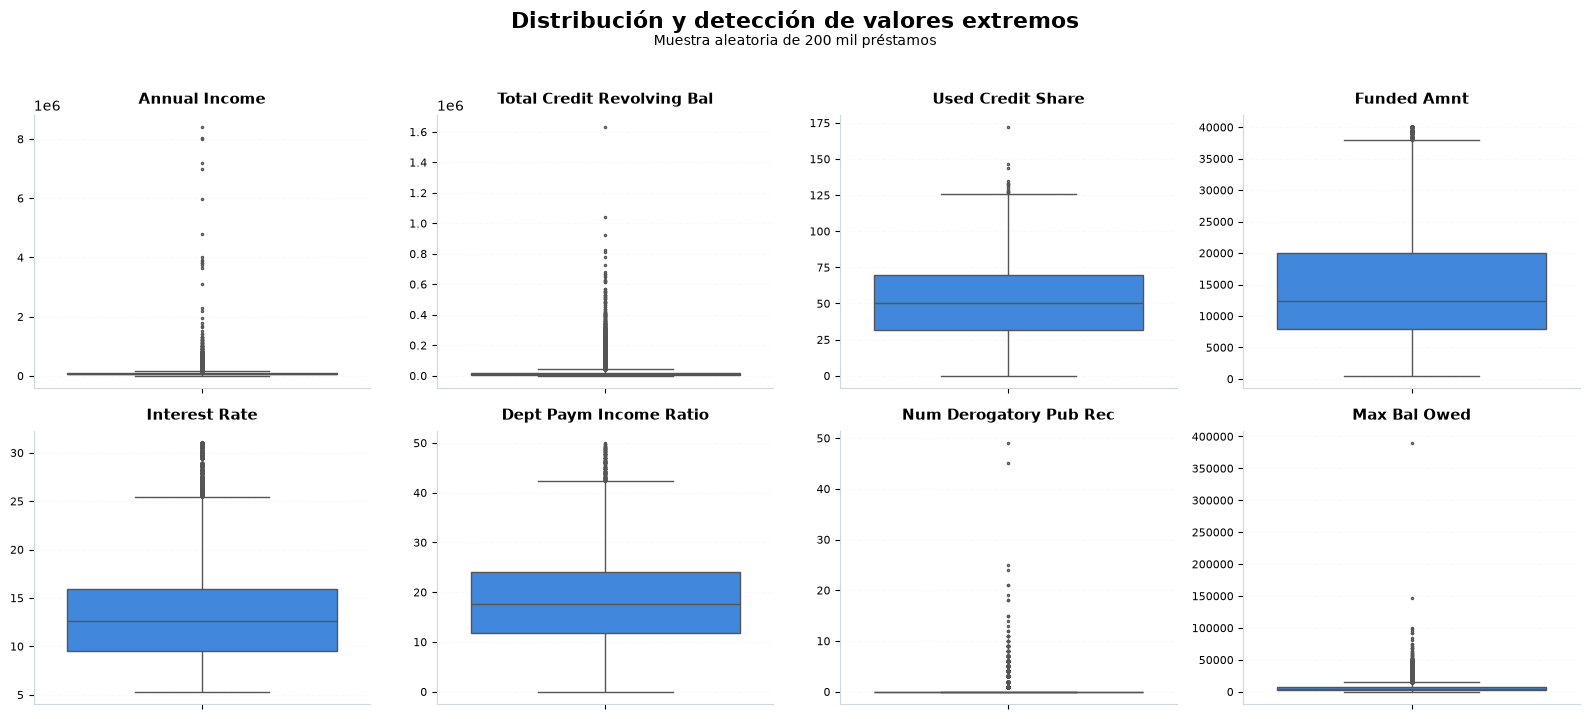

In [16]:
box_vars = [
    "annual_income",
    "total_credit_revolving_bal",
    "used_credit_share",
    "funded_amnt",
    "interest_rate",
    "dept_paym_income_ratio",
    "num_derogatory_pub_rec",
    "max_bal_owed"
]

# Muestra para visualización
sample_box = (
    df.select(box_vars)
      .sample(n=200_000, seed=RANDOM_STATE)
      .to_pandas()
)

fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 7)
)

for ax, col in zip(axes.flat, box_vars):

    sns.boxplot(
        y=sample_box[col],
        ax=ax,
        color="#2784F5",
        fliersize=1.5,
        linewidth=1
    )

    # Título
    ax.set_title(
        col.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold",
        pad=8
    )

    # Ejes
    ax.set_ylabel("")

    # Grid
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.20
    )
    ax.set_axisbelow(True)

    # Limpiar bordes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Ticks
    ax.tick_params(
        axis="both",
        labelsize=8
    )

plt.suptitle(
    "Distribución y detección de valores extremos",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.97,
    "Muestra aleatoria de 200 mil préstamos",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()



**TRATAMIENTO DE OUTLIERS** 
- Para las siguientes variables continuas `total_credit_revolving_bal` & `total_credit_revolving_bal`, `annual_income`, `max_bal_owed`, `used_credit_share`, aplicamos la winsorización de maximo al p99.5. Y posible evaluación logaritmica para las asimetrias. Para modelo de RL. 

## Análisis bivariante

In [17]:
variables = [
    "interest_rate", 
    "dept_paym_income_ratio",
    "annual_income",
    "funded_amnt",
    "num_derogatory_pub_rec",
    "num_30+_delinq_in_2yrs",
    "used_credit_share", 
    "tot_num_credit_lines"
]

agg = (
    df
    .group_by([TARGET])
    .agg([pl.col(col).median().alias(col) for col in variables])
    )
    
with pl.Config(tbl_rows = -1, tbl_cols = -1):
    print(agg)

shape: (2, 9)
┌─────┬───────────┬───────────┬───────────┬───────────┬───────────┬──────────┬──────────┬──────────┐
│ y   ┆ interest_ ┆ dept_paym ┆ annual_in ┆ funded_am ┆ num_derog ┆ num_30+_ ┆ used_cre ┆ tot_num_ │
│ --- ┆ rate      ┆ _income_r ┆ come      ┆ nt        ┆ atory_pub ┆ delinq_i ┆ dit_shar ┆ credit_l │
│ i64 ┆ ---       ┆ atio      ┆ ---       ┆ ---       ┆ _rec      ┆ n_2yrs   ┆ e        ┆ ines     │
│     ┆ f64       ┆ ---       ┆ f64       ┆ f64       ┆ ---       ┆ ---      ┆ ---      ┆ ---      │
│     ┆           ┆ f64       ┆           ┆           ┆ f64       ┆ f64      ┆ f64      ┆ f64      │
╞═════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪══════════╪══════════╪══════════╡
│ 0   ┆ 12.12     ┆ 17.31     ┆ 67000.0   ┆ 12000.0   ┆ 0.0       ┆ 0.0      ┆ 49.7     ┆ 22.0     │
│ 1   ┆ 14.99     ┆ 19.57     ┆ 60000.0   ┆ 14125.0   ┆ 0.0       ┆ 0.0      ┆ 55.3     ┆ 23.0     │
└─────┴───────────┴───────────┴───────────┴───────────┴───────────┴──────────

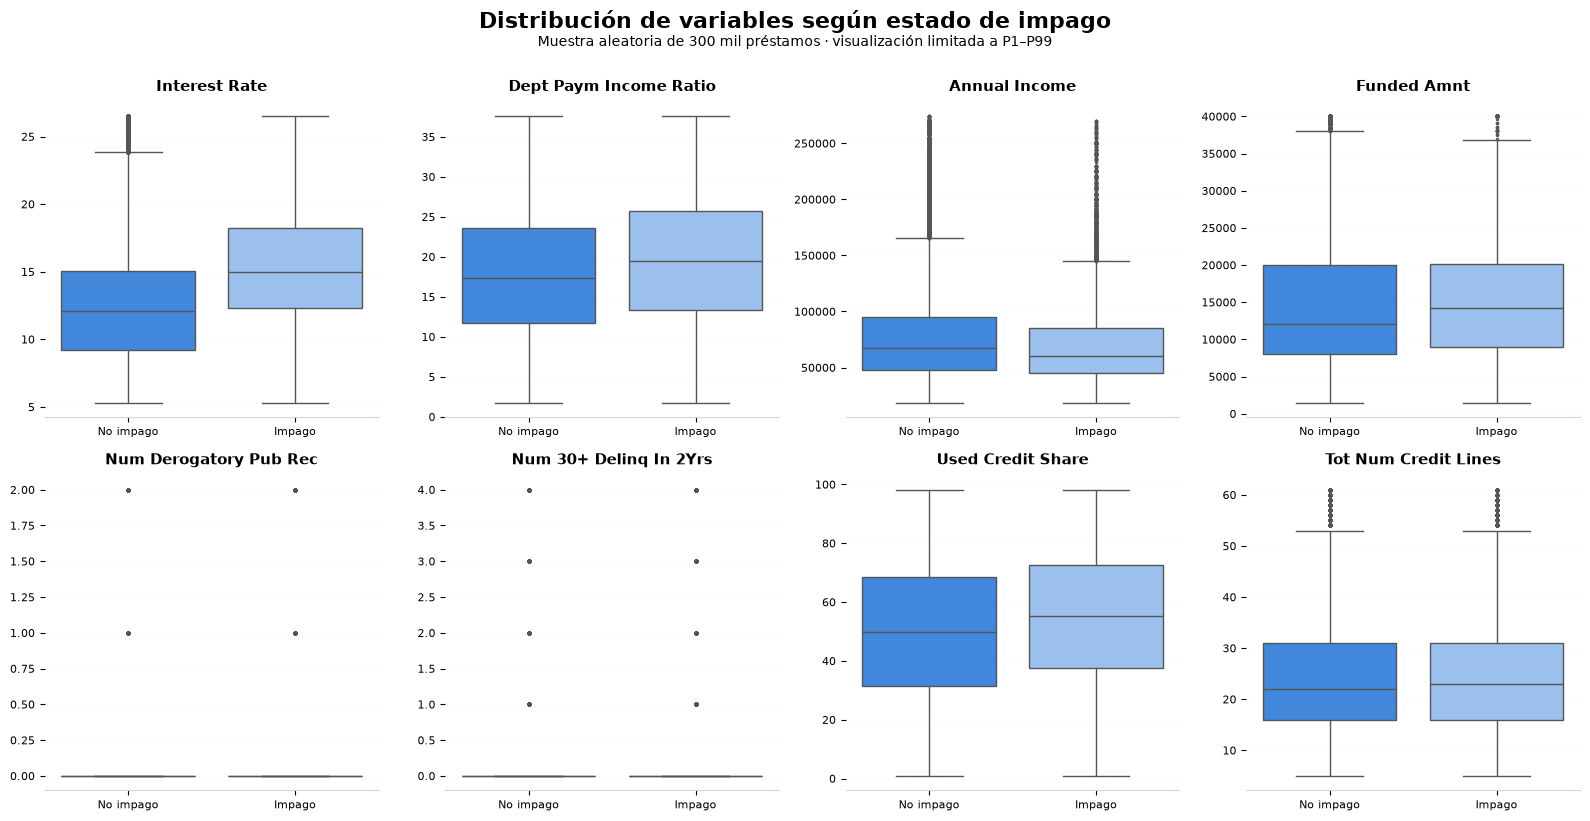

In [18]:
fig, axes = plt.subplots(2,4,figsize=(16, 8))

# Muestra para visualización
sample = (
    df.select(variables + [TARGET])
      .sample(n=300_000, seed=RANDOM_STATE)
      .to_pandas()
)

# Etiquetas del target
sample[TARGET] = sample[TARGET].map({
    0: "No impago",
    1: "Impago"
})

for ax, col in zip(axes.flat, variables):

    # P1-P99 solo para visualización
    lower = sample[col].quantile(0.01)
    upper = sample[col].quantile(0.99)

    data = sample[sample[col].between(lower, upper)]

    # Boxplot
    sns.boxplot(
        data=data,
        x=TARGET,
        y=col,
        hue=TARGET,
        palette=["#2784F5", "#8FBFFA"],
        showfliers=True,
        fliersize=1.5,
        linewidth=1,
        ax=ax,
        legend=False
    )

    # Título
    ax.set_title(
        col.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold",
        pad=8
    )

    # Ejes
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Grid
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.20
    )

    ax.set_axisbelow(True)

    # Bordes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Ticks
    ax.tick_params(
        axis="both",
        labelsize=8
    )

# Título general
plt.suptitle(
    "Distribución de variables según estado de impago",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

# Subtítulo
fig.text(
    0.5,
    0.975,
    "Muestra aleatoria de 300 mil préstamos · visualización limitada a P1–P99",
    ha="center",
    fontsize=10
)

plt.tight_layout()

plt.show()

Se obserca que `interest_rate` y `dept_paym_income_ratio` son mas altos en el grupo de impago, y tiene sentido con la lógica del negocio. Sin embargo, en `annual income` es mejor en el grupo de impago. 

In [19]:
def default_rate_by_bucket(
    df: pl.DataFrame,
    column: str,
    n_buckets: int = 10
) -> pl.DataFrame:
    """
    Calcula la tasa de impago por grupos (buckets) de una variable numérica.

    Parameters
    ----------
    df : pl.DataFrame
        DataFrame con la variable y el target.
    column : str
        Variable numérica a analizar.
    n_buckets : int
        Número de buckets deseados.

    Returns
    -------
    pl.DataFrame
        Tasa de impago y número de préstamos por bucket.
    """

    data = (df.select([column, TARGET]).drop_nulls())

    # Crear buckets según cuantiles
    data = data.with_columns(
        pl.col(column)
        .qcut(
            n_buckets,
            allow_duplicates=True
        )
        .alias("bucket")
    )

    # Calcular tasa de impago y número de préstamos
    result = (
        data
        .group_by("bucket")
        .agg(
            pl.col(TARGET).mean().alias("tasa_impago"),
            pl.len().alias("n")
        )
        .sort("bucket")
    )

    return result

In [20]:
for col in ["interest_rate", "dept_paym_income_ratio"]:
    print(f"\n--- {col} ---")
    print(default_rate_by_bucket(df, col, n_buckets=8 ))


--- interest_rate ---
shape: (8, 3)
┌────────────────┬─────────────┬────────┐
│ bucket         ┆ tasa_impago ┆ n      │
│ ---            ┆ ---         ┆ ---    │
│ cat            ┆ f64         ┆ u32    │
╞════════════════╪═════════════╪════════╡
│ (-inf, 7.62]   ┆ 0.029587    ┆ 274073 │
│ (11.06, 12.62] ┆ 0.112051    ┆ 269324 │
│ (12.62, 13.99] ┆ 0.147917    ┆ 279968 │
│ (13.99, 15.88] ┆ 0.158424    ┆ 249621 │
│ (15.88, 18.55] ┆ 0.201635    ┆ 267474 │
│ (18.55, inf]   ┆ 0.255793    ┆ 265977 │
│ (7.62, 9.49]   ┆ 0.06547     ┆ 268245 │
│ (9.49, 11.06]  ┆ 0.079038    ┆ 264961 │
└────────────────┴─────────────┴────────┘

--- dept_paym_income_ratio ---
shape: (8, 3)
┌────────────────┬─────────────┬────────┐
│ bucket         ┆ tasa_impago ┆ n      │
│ ---            ┆ ---         ┆ ---    │
│ cat            ┆ f64         ┆ u32    │
╞════════════════╪═════════════╪════════╡
│ (-inf, 8.16]   ┆ 0.098513    ┆ 267995 │
│ (11.78, 14.74] ┆ 0.112058    ┆ 266943 │
│ (14.74, 17.6]  ┆ 0.121804    ┆ 26

La tasa de impago crece a medida que `interest_rate` y `dept_paym_income_ratio` crecen, lo cual tiene mucho sentido para el desarrollo del modelo. 

In [21]:
cat = ["home_ownership_status", "verification_status", "loan_purpose"]

for col in cat:
    rate = (
        df
        .group_by(col)
        .agg(pl.col(TARGET)
        .mean()
        .alias("tasa_impago"),
        pl.
        len()
        .alias("n"))
        .sort("tasa_impago", descending=True))
        
    print(f"\n--- {col} ---")
    print(rate)


--- home_ownership_status ---
shape: (4, 3)
┌───────────────────────┬─────────────┬─────────┐
│ home_ownership_status ┆ tasa_impago ┆ n       │
│ ---                   ┆ ---         ┆ ---     │
│ str                   ┆ f64         ┆ u32     │
╞═══════════════════════╪═════════════╪═════════╡
│ RENT                  ┆ 0.15015     ┆ 865430  │
│ OWN                   ┆ 0.129376    ┆ 241591  │
│ MORTGAGE              ┆ 0.114798    ┆ 1031398 │
│ OTHER                 ┆ 0.093137    ┆ 1224    │
└───────────────────────┴─────────────┴─────────┘

--- verification_status ---
shape: (3, 3)
┌─────────────────────┬─────────────┬────────┐
│ verification_status ┆ tasa_impago ┆ n      │
│ ---                 ┆ ---         ┆ ---    │
│ str                 ┆ f64         ┆ u32    │
╞═════════════════════╪═════════════╪════════╡
│ Verified            ┆ 0.174238    ┆ 587726 │
│ Source Verified     ┆ 0.134669    ┆ 851804 │
│ Not Verified        ┆ 0.089414    ┆ 700113 │
└─────────────────────┴─────────────

`verification_status` muestra un patrón contraintuitivo a primera vista — los ingresos "Verified" no necesariamente tienen menor tasa de impago que "Not Verified"; esto es habitual en Lending Club porque la verificación se aplica de forma más sistemática a solicitudes con perfiles ya considerados de mayor riesgo, así que la propia variable "verification_status" está parcialmente confundida con el proceso de originación. `home_ownership_status` y `loan_purpose` sí muestran diferenciación de riesgo razonable y en línea con la intuición de negocio (p. ej. `small_business` con mayor tasa de impago que `credit_card`).

## Análisis de correlación 

,funded_amnt,interest_rate,monthly_payment,dept_paym_income_ratio,used_credit_share,tot_num_credit_lines,num_open_credit_lines,y
0,1.000000,0.099381,0.947086,0.022572,0.103657,0.206740,0.187942,0.031688
1,0.099381,1.000000,0.122446,0.186058,0.259512,-0.039512,-0.010442,0.211219
2,0.947086,0.122446,1.000000,0.028295,0.123152,0.184601,0.175797,0.036114
3,0.022572,0.186058,0.028295,1.000000,0.180894,0.247008,0.304988,0.076782
4,0.103657,0.259512,0.123152,0.180894,1.000000,-0.096539,-0.137839,0.064329
5,0.206740,-0.039512,0.184601,0.247008,-0.096539,1.000000,0.716264,0.013526
6,0.187942,-0.010442,0.175797,0.304988,-0.137839,0.716264,1.000000,0.018132
7,0.031688,0.211219,0.036114,0.076782,0.064329,0.013526,0.018132,1.000000


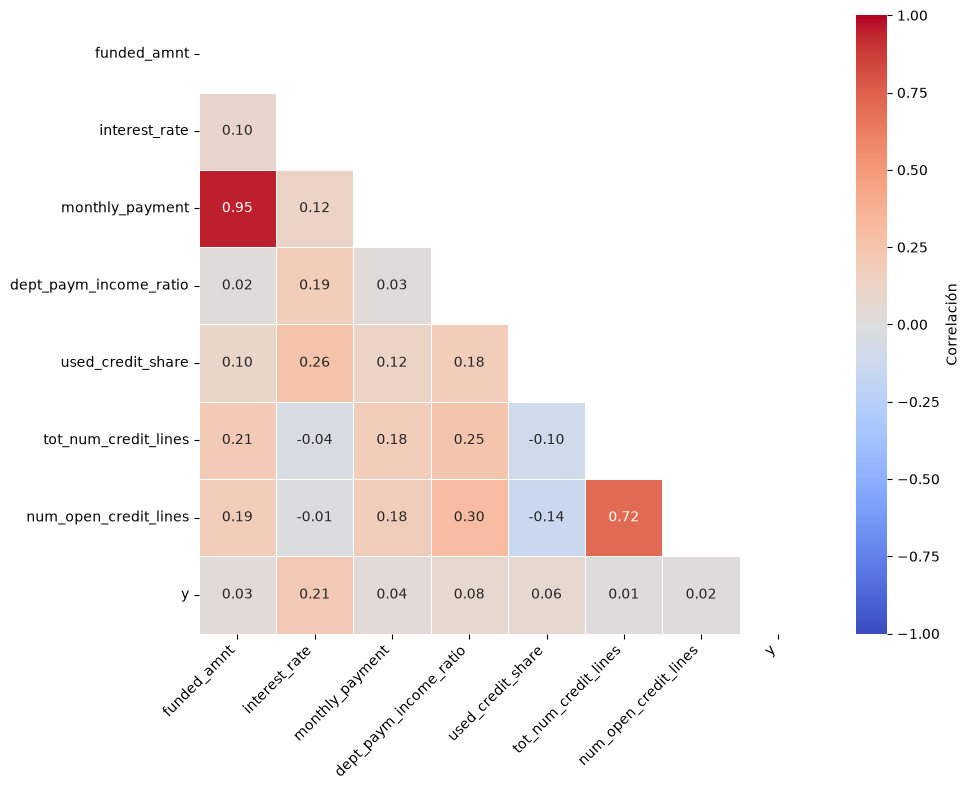

In [22]:
# Ahora graficaremos usando 
cols_clave = ['funded_amnt', 'interest_rate', 'monthly_payment',
              'dept_paym_income_ratio', 'used_credit_share',
              'tot_num_credit_lines', 'num_open_credit_lines', 'y']
              
correlation_matrix = (df[cols_clave].drop_nulls().corr().to_pandas())

display(correlation_matrix)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlación"}
)

ax.set_yticklabels(
    correlation_matrix.columns,
    rotation=0
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

Vemos que existn variables que estan muy correlacionadas como lo es `funded_amnt` y `monthly_payment`, además vemos que `interest_rate` afecta de manera positiva a la nuestra variable objetivo `y`, lo cual tiene mucho sentido. Ahora verificaremos con el VIF que variables podemos restringir para un modelo lineal como Regresión Logística! 

## Ingenieria de variables

1. **Antigüedad crediticia en meses** (`antiguedad_crediticia_meses`): tiempo entre la apertura de la primera línea de crédito (`earliest_cr_line_month/year`) y la fecha de originación del préstamo (`issue_date_month/year`). Una historia crediticia más larga suele asociarse a menor riesgo.

2. **Ratio de financiación sobre ingresos** (`ratio_financiacion_ingreso`): `funded_amnt / annual_income`. Complementa a `dept_paym_income_ratio` (que mira la cuota mensual) mirando el importe total solicitado frente a la capacidad anual del cliente.

3. **Codificación ordinal de `emp_length`**: pasa de texto (`"< 1 year"`, ..., `"10+ years"`) a un número, porque es una variable con orden natural.

4. **Transformación logarítmica** de las variables monetarias con cola larga (`annual_income`, `funded_amnt`, `total_credit_revolving_bal`).


Otras variables a tener en cuenta para futuros análisis o mejoras del modelo: 

1. Agrupación de la variable `emp_title` en un top-20 categorias más frecuentes + otros, una forma de resumir las ~497k categorias. 
2. Antigüedad relativa de la solicitud: `anios_desde_originacion` a partir de `issue_date_year`, útil para detectar/controlar efectos de cosecha (*vintage*) en el histórico.



In [23]:
meses = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}


mapa_emp_length = {
    # "Desconocido": -1,
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
}


df = df.with_columns([
    # 1. antiguedad crediticia: ¿Cuántos meses de historial crediticio tenía el cliente cuando obtuvo el préstamo?
    # ((año originación - año primera línea) × 12) +(mes originación - mes primera línea)
    (
        (pl.col('issue_date_year').cast(pl.Int32) - pl.col('earliest_cr_line_year').cast(pl.Int32)) * 12  + 
        (pl.col('issue_date_month').replace_strict(meses, return_dtype=pl.Int32) - pl.col('earliest_cr_line_month').replace_strict(meses, return_dtype=pl.Int32))
    ).alias("antiguedad_crediticia_meses"),

    # 2. ratio de financiacion / ingreso
    # ejemplo: funded_amnt = 10k ; annual_income = 50k entonces: 10k/50K = 0.20
    # el prestamo representa el 20% del ingreso anual. 
    (
        pl.col('funded_amnt') / pl.col('annual_income').clip(lower_bound=1)
    ).alias('ratio_financiacion_ingreso'),

    #3. emp_length a ordinal
    (
        pl.col('emp_length').replace_strict(mapa_emp_length, default=-1, return_dtype=pl.Int32)
    ).alias('emp_length_ordinal'),

    #4. Transformación log para variabkles con simetria simetrica postiva
    pl.col('annual_income').log1p().alias('log_annual_income'),
    pl.col('funded_amnt').log1p().alias('log_funded_amnt'),
    pl.col('total_credit_revolving_bal').log1p().alias('log_total_credit_revolving_bal')

])


## Limpieza básica

- Dado que la variable `dept_paym_income_ratio` cuenta con un único elemento -1 de ~2.1M de registros, es más que probable que sea un error de calculo o de registro, por ello se reemplazará por 0, ya que no afectaría a nuestro modelo. 

- Para la variable `emp_title`, dado que tiene ~47k categorías, se le reemplazará con `unknow`. Probablemente después del modelo, se podria acotar estas categóricas a un número reducido.  

In [24]:
# Remplazamos el único elemento -1 con 0
df = df.with_columns(
    pl.col('dept_paym_income_ratio')
    .replace(-1, 0))

# Reeplazaremos a las nulls con la etiqueta de Unknown
df = df.with_columns(
    pl.col('emp_title').fill_null('Unknown')
)

In [25]:
n_filas = df.height

resumen_filas = []

df[ORIG_VARS].columns

for c in df[ORIG_VARS].columns:
    n_missing = df[c].null_count()
    resumen_filas.append({
        'columna' : c,
        'dtype' : str(df.schema[c]),
        'n_unicos': df[c].n_unique(),
        'n_missing': n_missing,
        'pct_missing':round(n_missing/n_filas * 100, 2)
    })

resumen = pl.DataFrame(resumen_filas).sort('pct_missing', descending = True)

with pl.Config(tbl_rows = -1):
    print(resumen.filter(pl.col('n_missing') > 0))

shape: (12, 5)
┌────────────────────────────────────┬───────┬──────────┬───────────┬─────────────┐
│ columna                            ┆ dtype ┆ n_unicos ┆ n_missing ┆ pct_missing │
│ ---                                ┆ ---   ┆ ---      ┆ ---       ┆ ---         │
│ str                                ┆ str   ┆ i64      ┆ i64       ┆ f64         │
╞════════════════════════════════════╪═══════╪══════════╪═══════════╪═════════════╡
│ mths_since_recent_bankcard_delinq  ┆ Int64 ┆ 177      ┆ 1643502   ┆ 76.81       │
│ mths_since_recent_revol_delinq     ┆ Int64 ┆ 178      ┆ 1433891   ┆ 67.02       │
│ mths_since_last_delinq             ┆ Int64 ┆ 173      ┆ 1090997   ┆ 50.99       │
│ mths_since_last_installment_acc_op ┆ Int64 ┆ 404      ┆ 905256    ┆ 42.31       │
│ num_open_trades_in_6mths           ┆ Int64 ┆ 20       ┆ 865656    ┆ 40.46       │
│ num_installment_acc_op_in_12mths   ┆ Int64 ┆ 20       ┆ 865656    ┆ 40.46       │
│ num_installment_acc_op_in_24mths   ┆ Int64 ┆ 32       ┆ 865

In [26]:
df_processed = df.select(ORIG_VARS + LEAKAGE_VARS)

df_processed.write_parquet("../data/interim/features_orig.parquet")